In [1]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import signal
import numpy as np
import scipy.io.wavfile as wavfile
import pygame
from fft import fft
import soundfile as sf
import librosa

FILEPATH = 'audios/rec/'
FILENAME = 'rec3.wav'
FILE = FILEPATH + FILENAME

pygame 2.3.0 (SDL 2.24.2, Python 3.9.16)
Hello from the pygame community. https://www.pygame.org/contribute.html


Bandstop Filter
<br> 
Not good

rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


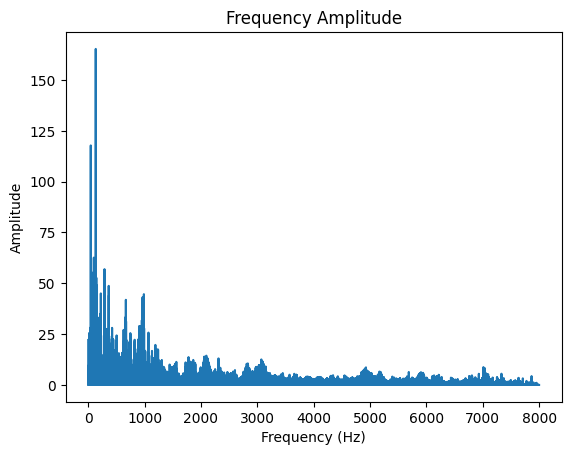

bandstop_rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


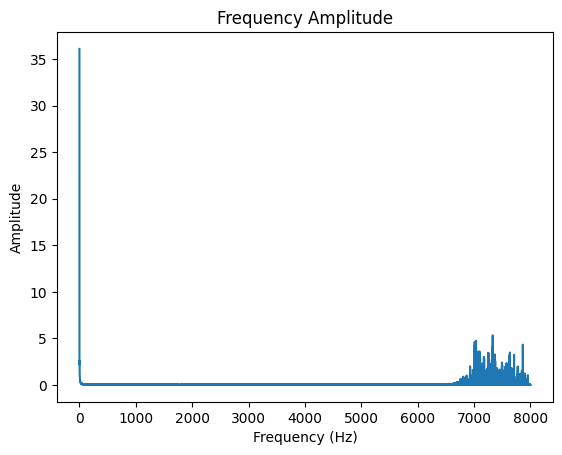

In [2]:
# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Define the frequency range to remove (in Hz)
f_low = 1
f_high = 7000

# Create a bandstop filter with the desired frequency range
nyquist = 0.5 * sr
f_low_norm = f_low / nyquist
f_high_norm = f_high / nyquist
b, a = signal.butter(4, [f_low_norm, f_high_norm], btype='bandstop')

# Apply the filter to the audio signal
audio_filtered = signal.filtfilt(b, a, audio_file)

# Save the filtered audio file
FILTERED_AUDIO = f'audios/filtered_audio/bandstop/bandstop_{FILENAME}'
sf.write(FILTERED_AUDIO, audio_filtered, 16000)

fft(FILE)
fft(FILTERED_AUDIO, True)


Bandpass Filter
<br> 
Not good

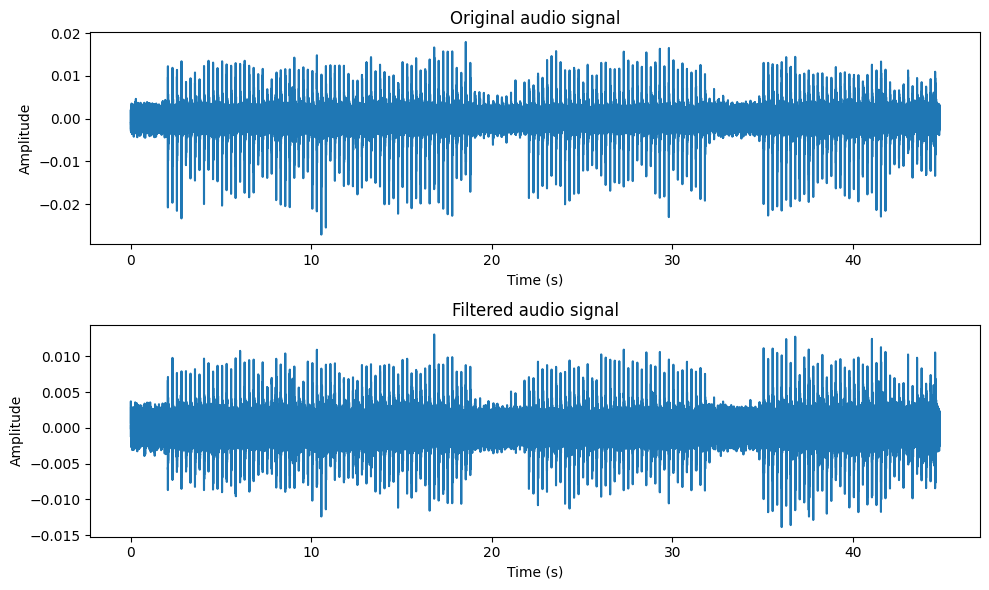

rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


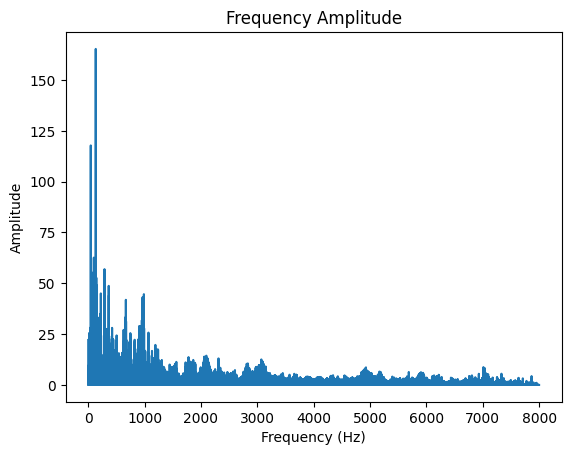

bandpass_rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


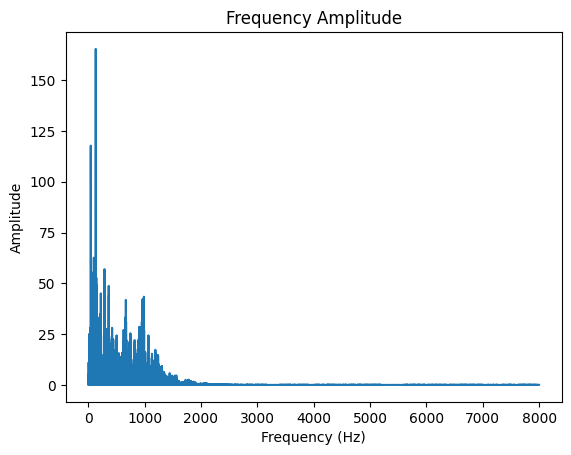

In [3]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Define the frequency range to keep (in Hz)
# f_high max 5500 everything after 6500 is only noise
f_low = 10
f_high = 1500

# Create a bandpass filter with the desired frequency range
nyquist = 0.5 * sr
f_low_norm = f_low / nyquist
f_high_norm = f_high / nyquist
b, a = signal.butter(4, [f_low_norm, f_high_norm], btype='band')

# Apply the filter to the audio signal
audio_filtered = signal.filtfilt(b, a, audio_file)

# Plot the original and filtered signals
t = np.arange(len(audio_file)) / sr
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(t, audio_file)
ax[0].set_title('Original audio signal')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[1].plot(t, audio_filtered)
ax[1].set_title('Filtered audio signal')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Save the filtered audio file
FILTERED_AUDIO = f'audios/filtered_audio/bandpass/bandpass_{FILENAME}'
sf.write(FILTERED_AUDIO, audio_filtered, 16000)

fft(FILE)
fft(FILTERED_AUDIO, True)


Highpass Filter
<br> 
Not good

rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


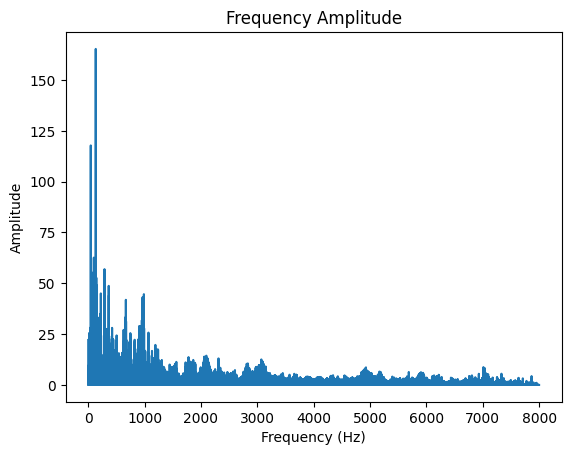

highpass_rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


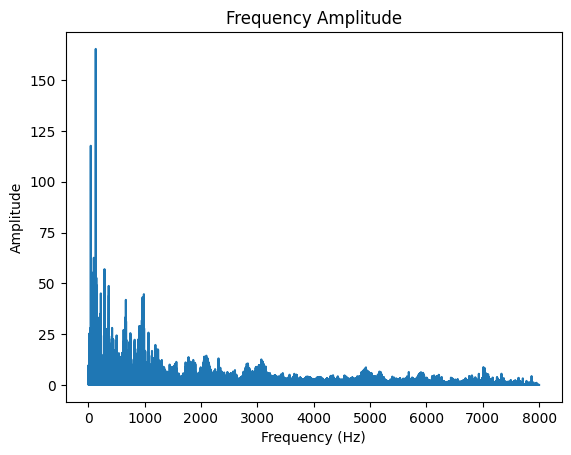

In [4]:
# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Define the frequency range to remove (in Hz)
f_cutoff = 1

# Create a bandstop filter with the desired frequency range
nyquist = 0.5 * sr
f_cutoff_norm = f_cutoff / nyquist
b, a = signal.butter(4, f_cutoff_norm, btype='highpass')

# Apply the filter to the audio signal
audio_filtered = signal.filtfilt(b, a, audio_file)

# Save the filtered audio file
FILTERED_AUDIO = f'audios/filtered_audio/highpass/highpass_{FILENAME}'
sf.write(FILTERED_AUDIO, audio_filtered, 16000)

fft(FILE)
fft(FILTERED_AUDIO, True)


Finite Impulse Response (FIR)

rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


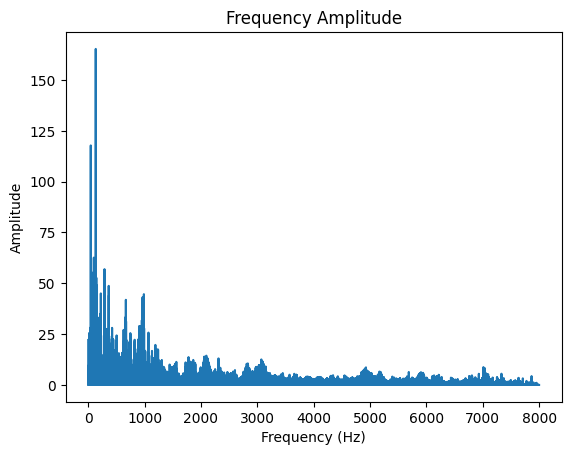

fir_rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


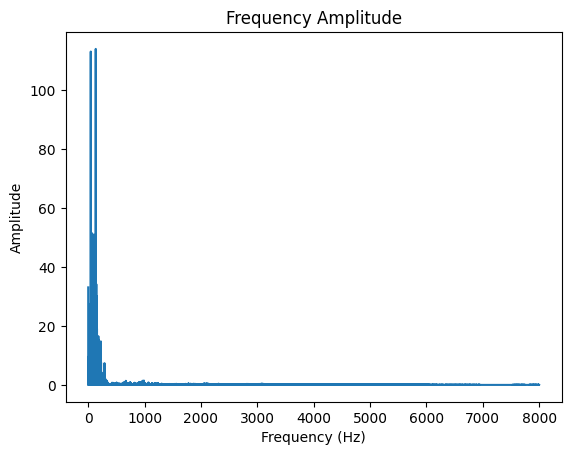

In [5]:
# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Define the frequency range to remove (in Hz)
f_low = 0
f_high = 6000

# Define the filter order
order = 101

# Create a windowed sinc filter with the desired frequency range and order
nyquist = 0.5 * sr
t = np.linspace(-order / 2, order / 2, order, endpoint=False) / sr
sinc = np.sinc(2 * f_high * t) - np.sinc(2 * f_low * t)
window = np.blackman(order)
sinc_windowed = sinc * window
sinc_windowed /= np.sum(sinc_windowed)

# Apply the filter to the audio signal
audio_filtered = signal.convolve(audio_file, sinc_windowed, mode='same')

# Save the filtered audio file
FILTERED_AUDIO = f'audios/filtered_audio/fir/fir_{FILENAME}'
sf.write(FILTERED_AUDIO, audio_filtered, 16000)

fft(FILE)
fft(FILTERED_AUDIO)


Get loudest frequency in FTT

In [6]:
import numpy as np
import librosa

# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Compute the FFT of the audio signal
fft = np.abs(np.fft.rfft(audio_file))

# Find the frequencies with the highest amplitudes
freqs = np.fft.rfftfreq(len(audio_file), 1/sr)
rounded_freqs = np.round(freqs).astype(int)
unique_rounded_freqs = np.unique(rounded_freqs)
max_freqs = []
for freq in unique_rounded_freqs:
    if freq == 0:
        continue
    indices = np.where(rounded_freqs == freq)[0]
    max_index = indices[np.argmax(fft[indices])]
    max_freq = freqs[max_index]
    max_freqs.append(max_freq)

# Sort the frequencies by amplitude in descending order
max_freqs_sorted = sorted(max_freqs, key=lambda f: -fft[np.argmax(freqs == f)])

# Print the top 5 frequencies with the highest amplitudes
for i in range(10):
    freq = max_freqs_sorted[i]
    amp = fft[np.argmax(freqs == freq)]
    print(f'Top {i+1}: {freq:.1f} Hz (amplitude={amp:.2f})')


Top 1: 133.7 Hz (amplitude=165.32)
Top 2: 45.5 Hz (amplitude=117.84)
Top 3: 100.0 Hz (amplitude=62.64)
Top 4: 289.0 Hz (amplitude=56.97)
Top 5: 60.0 Hz (amplitude=55.45)
Top 6: 144.0 Hz (amplitude=52.73)
Top 7: 64.0 Hz (amplitude=50.25)
Top 8: 152.0 Hz (amplitude=48.98)
Top 9: 364.0 Hz (amplitude=48.74)
Top 10: 148.0 Hz (amplitude=46.72)
